# Новицкий Ярослав ИУ5-65Б РК2

## Вариант 12  

### 1. Импорт библиотек и загрузка данных

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [166]:
df = pd.read_csv("dc-wikia-data.csv")
df.head()

,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,YEAR
0,1422,Batman (Bruce Wayne),\/wiki\/Batman_(Bruce_Wayne),Secret Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3093.0,"1939, May",1939.0
1,23387,Superman (Clark Kent),\/wiki\/Superman_(Clark_Kent),Secret Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,2496.0,"1986, October",1986.0
2,1458,Green Lantern (Hal Jordan),\/wiki\/Green_Lantern_(Hal_Jordan),Secret Identity,Good Characters,Brown Eyes,Brown Hair,Male Characters,NaN,Living Characters,1565.0,"1959, October",1959.0
3,1659,James Gordon (New Earth),\/wiki\/James_Gordon_(New_Earth),Public Identity,Good Characters,Brown Eyes,White Hair,Male Characters,NaN,Living Characters,1316.0,"1987, February",1987.0
4,1576,Richard Grayson (New Earth),\/wiki\/Richard_Grayson_(New_Earth),Secret Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,1237.0,"1940, April",1940.0


### 2. Первичный анализ и отбор признаков

In [167]:
print("Размерность набора данных:", df.shape)

df = df[['ALIGN', 'EYE', 'HAIR', 'SEX', 'ALIVE', 'APPEARANCES', 'YEAR']]
print("\nПосле выбора признаков:")
df.head()


Размерность набора данных: (6896, 13)

После выбора признаков:


,ALIGN,EYE,HAIR,SEX,ALIVE,APPEARANCES,YEAR
0,Good Characters,Blue Eyes,Black Hair,Male Characters,Living Characters,3093.0,1939.0
1,Good Characters,Blue Eyes,Black Hair,Male Characters,Living Characters,2496.0,1986.0
2,Good Characters,Brown Eyes,Brown Hair,Male Characters,Living Characters,1565.0,1959.0
3,Good Characters,Brown Eyes,White Hair,Male Characters,Living Characters,1316.0,1987.0
4,Good Characters,Blue Eyes,Black Hair,Male Characters,Living Characters,1237.0,1940.0


### 3. Проверка пропусков

In [168]:
print("\nКоличество пропусков по столбцам:")
print(df.isnull().sum())


Количество пропусков по столбцам:
ALIGN           601
EYE            3628
HAIR           2274
SEX             125
ALIVE             3
APPEARANCES     355
YEAR             69
dtype: int64


### 4. Обработка пропущенных значений

In [169]:
# Удаление строк с отсутствием в категориальных признаках
df = df.dropna(subset=['ALIGN', 'EYE', 'HAIR', 'SEX', 'ALIVE'])

# Числовые признаки — медиана
df['APPEARANCES'] = df['APPEARANCES'].fillna(df['APPEARANCES'].median())
df['YEAR'] = df['YEAR'].fillna(df['YEAR'].median())

print("\nКоличество пропусков после обработки:")
print(df.isnull().sum())


Количество пропусков после обработки:
ALIGN          0
EYE            0
HAIR           0
SEX            0
ALIVE          0
APPEARANCES    0
YEAR           0
dtype: int64


### 5. Распределение целевого признака

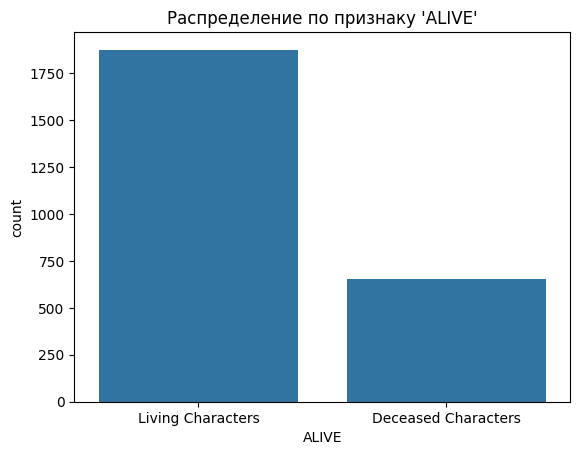

In [170]:
sns.countplot(x='ALIVE', data=df)
plt.title("Распределение по признаку 'ALIVE'")
plt.show()

### 6. Кодирование категориальных признаков

In [171]:
label_encoders = {}
for col in ['ALIGN', 'EYE', 'HAIR', 'SEX', 'ALIVE']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\nПервые строки после кодирования:")
df.head()


Первые строки после кодирования:


,ALIGN,EYE,HAIR,SEX,ALIVE,APPEARANCES,YEAR
0,1,2,0,2,1,3093.0,1939.0
1,1,2,0,2,1,2496.0,1986.0
2,1,3,3,2,1,1565.0,1959.0
3,1,3,16,2,1,1316.0,1987.0
4,1,2,0,2,1,1237.0,1940.0


### 7. Подготовка данных

In [172]:
X = df.drop(columns='ALIVE')
y = df['ALIVE']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("\nРазмер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)


Размер обучающей выборки: (2021, 6)
Размер тестовой выборки: (506, 6)


### 8. Обучение модели SVM и оценка

In [173]:
svm_model = SVC(class_weight='balanced')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm, average='macro')

print("Метод опорных векторов (SVM) с балансировкой:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score (macro): {f1:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

Метод опорных векторов (SVM) с балансировкой:
Accuracy: 0.5395
F1-score (macro): 0.5227
Classification Report:
               precision    recall  f1-score   support

           0       0.32      0.65      0.43       136
           1       0.80      0.50      0.61       370

    accuracy                           0.54       506
   macro avg       0.56      0.58      0.52       506
weighted avg       0.67      0.54      0.56       506



### 9. Обучение модели градиентного бустинга

In [174]:
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_gb)
f1 = f1_score(y_test, y_pred_gb)

print("Градиентный бустинг:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_gb))

Градиентный бустинг:
Accuracy: 0.7233
F1-score: 0.8383
Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.02      0.04       136
           1       0.73      0.98      0.84       370

    accuracy                           0.72       506
   macro avg       0.52      0.50      0.44       506
weighted avg       0.62      0.72      0.62       506



### Классификация или регрессия?

В данной задаче используется **классификация**, так как целевая переменная `ALIVE` (жив/мертв) принимает **дискретные значения**, а не непрерывные. Мы предсказываем категорию, а не числовую величину.

### Какие метрики качества использовались и почему?

Для оценки моделей использовались следующие метрики:

* **Accuracy** — доля правильно предсказанных наблюдений. Удобна для оценки общей точности, но чувствительна к дисбалансу классов.
* **F1-score (macro)** — гармоническое среднее между точностью и полнотой. Лучше подходит при наличии классов с разным количеством объектов, так как учитывает как ложные положительные, так и ложные отрицательные с равным весом.

Использование обеих метрик позволяет получить более объективную оценку качества классификации при дисбалансе классов.

### Выводы о качестве построенных моделей

* **Метод опорных векторов (SVM)** с балансировкой классов показал **низкую точность** (accuracy ≈ 54%) и **среднее значение F1-score** (≈ 0.52). Несмотря на хорошие показатели полноты для класса 0 (65%), модель значительно уступает по точности и уверенности предсказаний (precision для класса 0 — всего 32%). Это говорит о том, что SVM не справляется с предсказанием редкого класса, но балансировка частично помогает учитывать оба класса.

* **Gradient Boosting Classifier** достиг **более высокой точности** (≈ 72%) и **высокого F1-score** (≈ 0.84) для доминирующего класса 1. Однако его **предсказания для класса 0 практически не работают** — f1-score всего 0.04. Это свидетельствует о том, что модель фокусируется почти исключительно на наиболее представленном классе, игнорируя редкие случаи.

* **Macro F1-score** у бустинга даже ниже, чем у SVM (0.44 против 0.52), что подчёркивает сильный дисбаланс в предсказаниях.

### Общий вывод:

* **SVM** лучше справляется с учётом меньшинства, но его общая точность и устойчивость страдают.
* **Градиентный бустинг** даёт высокую точность и уверенность для одного класса, но полностью игнорирует другой, что делает модель **непригодной для задач, где важны оба класса**.

